# Credit Scorecard Development
## Notebook 3 — Scorecard Model Development

This notebook builds the final credit scorecard:
1. WoE-transform selected features
2. Train logistic regression on WoE features
3. Scale log-odds to credit score points (PDO method)
4. Analyze score distribution and feature contributions

**Score scaling parameters:**
- Base Score = 600 (corresponds to odds of 50:1)
- PDO = 20 (every 20 points → odds double)

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import load_credit_data, train_test_split_time, WoEBinner, CreditScorecard

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

df = load_credit_data()
df_train, df_test = train_test_split_time(df, test_size=0.3)

features = ['age', 'annual_income', 'credit_utilization', 'num_delinquencies',
            'num_credit_accounts', 'debt_to_income', 'num_real_estate_loans', 'num_dependents']

print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')

Train: 105,000 | Test: 45,000


## 1. WoE Transformation & Feature Selection

In [2]:
binner = WoEBinner(max_bins=10)
binner.fit(df_train[features], df_train['default'], features=features)

iv_summary = binner.iv_summary()
selected_features = iv_summary[iv_summary['iv'] >= 0.02]['feature'].tolist()
woe_features = [f'{f}_woe' for f in selected_features]

X_train = binner.transform(df_train[features])[woe_features]
X_test  = binner.transform(df_test[features])[woe_features]
y_train = df_train['default']
y_test  = df_test['default']

print(f'Selected features ({len(selected_features)}): {selected_features}')

Selected features (6): ['credit_utilization', 'num_delinquencies', 'age', 'annual_income', 'num_credit_accounts', 'debt_to_income']


## 2. Train Scorecard Model

In [3]:
scorecard = CreditScorecard(base_score=600, base_odds=50, pdo=20, C=1.0)
scorecard.fit(X_train, y_train)

print('=== Scorecard Score Points per Feature ===')
summary = scorecard.score_summary()
print(summary.to_string(index=False))

=== Scorecard Score Points per Feature ===
                feature  coefficient  points_per_unit_woe
  num_delinquencies_woe     0.549049           -21.661282
 credit_utilization_woe     0.722104           -20.227826
     debt_to_income_woe     0.171038           -19.875004
                age_woe     0.246367           -12.912714
      annual_income_woe     0.071201            -7.878115
num_credit_accounts_woe     0.039946            -4.628902


## 3. Score Distribution

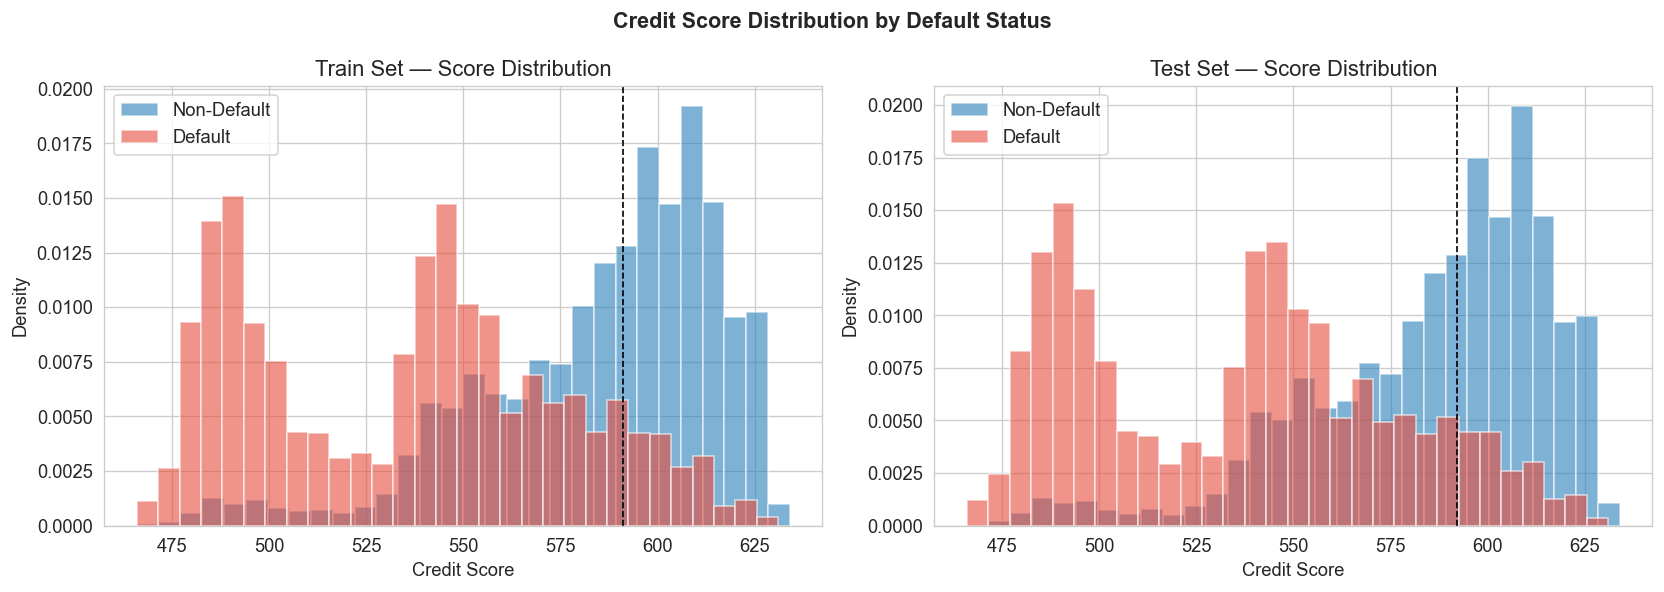

Train score range: 466 – 634  |  Mean: 582.5
Test  score range: 466 – 634  |  Mean: 582.7


In [4]:
train_scores = scorecard.predict_score(X_train)
test_scores  = scorecard.predict_score(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scores, label, ax in [(train_scores, 'Train', axes[0]), (test_scores, 'Test', axes[1])]:
    y_true = y_train if label == 'Train' else y_test
    for default_val, color, lbl in [(0, '#2980b9', 'Non-Default'), (1, '#e74c3c', 'Default')]:
        mask = (y_true == default_val).values
        ax.hist(scores[mask], bins=30, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(f'{label} Set — Score Distribution')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Density')
    ax.legend()
    ax.axvline(np.median(scores), color='black', linestyle='--', lw=1,
               label=f'Median={np.median(scores):.0f}')

plt.suptitle('Credit Score Distribution by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/03_score_distribution.png', bbox_inches='tight')
plt.show()

print(f'Train score range: {train_scores.min()} – {train_scores.max()}  |  Mean: {train_scores.mean():.1f}')
print(f'Test  score range: {test_scores.min()} – {test_scores.max()}  |  Mean: {test_scores.mean():.1f}')

## 4. Score vs Default Rate (Odds Validation)

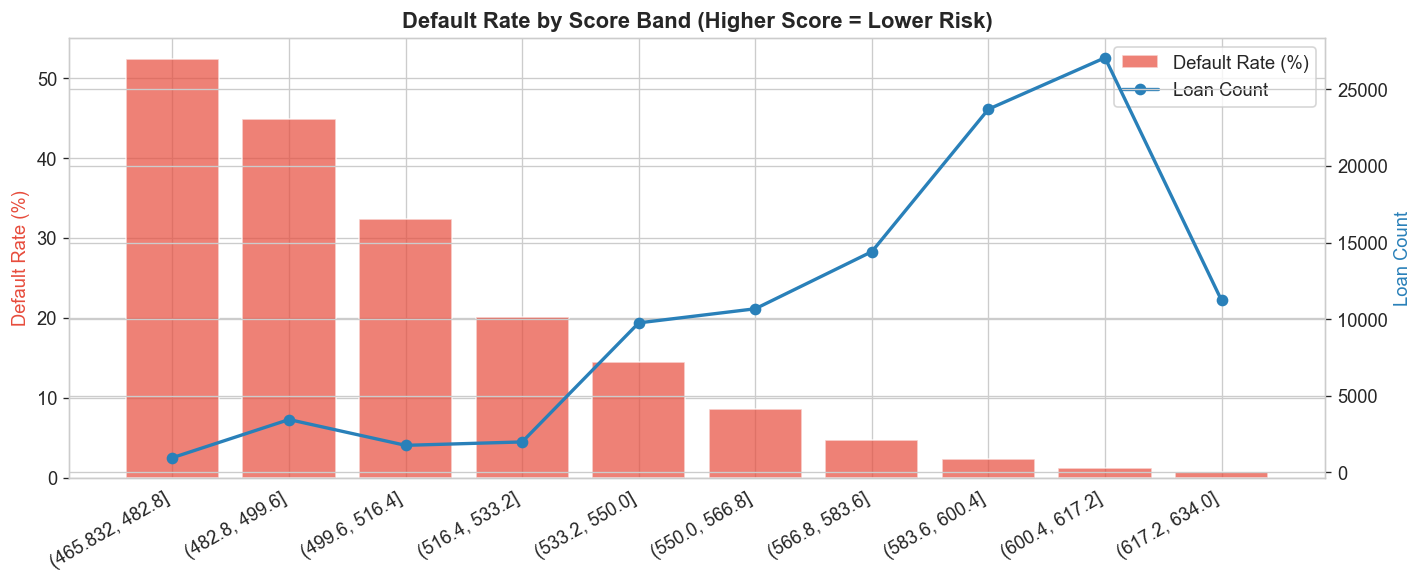

In [5]:
df_scored = pd.DataFrame({
    'score': train_scores, 'default': y_train.values
})
df_scored['score_band'] = pd.cut(df_scored['score'], bins=10)
score_dr = df_scored.groupby('score_band', observed=True)['default'].agg(['mean','count'])
score_dr.columns = ['default_rate', 'count']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(score_dr)), score_dr['default_rate'] * 100,
        color='#e74c3c', alpha=0.7, label='Default Rate (%)')
ax2.plot(range(len(score_dr)), score_dr['count'],
         'o-', color='#2980b9', linewidth=2, label='Loan Count')

ax1.set_xticks(range(len(score_dr)))
ax1.set_xticklabels([str(b) for b in score_dr.index], rotation=30, ha='right')
ax1.set_ylabel('Default Rate (%)', color='#e74c3c')
ax2.set_ylabel('Loan Count', color='#2980b9')
ax1.set_title('Default Rate by Score Band (Higher Score = Lower Risk)', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('../plots/03_score_vs_default_rate.png', bbox_inches='tight')
plt.show()